# Stock Market Forecasting Performance of Agentic Large Language Models
This notebook examines forecasting accuracy for the GPT-5-nano agent forecasts in `my_data.csv`. The goal is to evaluate day/week/month horizon performance, quantify forecast error, identify any trends, and assess systematic bias.


## Analysis Objectives
1. Load and validate the dataset.
2. Perform exploratory data analysis with emphasis on forecast and actual return behavior.
3. Compute forecast accuracy metrics for the day, week, and month horizons.
4. Investigate error patterns, bias, and statistical significance.
5. Provide supporting context with token usage and confidence labels.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import math

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.lines import Line2D

sns.set_theme(style='whitegrid', context='talk')

# Shared, readable defaults applied to every figure below: larger titles and
# tick labels, horizontal-only grid, a single muted bottom spine, no tick marks,
# tab10 colours, and an opaque white legend box.
mpl.rcParams.update({
    'figure.figsize': (12, 4), 'figure.dpi': 110,
    'savefig.dpi': 300, 'savefig.bbox': 'tight',

    'axes.titlesize': 15, 'axes.titleweight': 'bold', 'axes.titlepad': 12,
    'axes.titlecolor': '#1a1a1a',
    'axes.labelsize': 12, 'axes.labelcolor': '#444444',
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'xtick.color': '#444444', 'ytick.color': '#444444',
    'xtick.major.size': 0, 'ytick.major.size': 0,

    'legend.fontsize': 11, 'legend.frameon': True,
    'legend.facecolor': 'white', 'legend.edgecolor': 'none', 'legend.framealpha': 1.0,

    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'axes.edgecolor': '#cccccc',

    'axes.grid': True, 'axes.grid.axis': 'y', 'axes.axisbelow': True,
    'grid.color': '#e5e5e5', 'grid.linewidth': 0.8,
})


def style_axes(ax, ygrid=True):
    """Apply the shared finishing touches: muted bottom spine only, no tick
    marks, horizontal-only grid."""
    for spine in ('top', 'right', 'left'):
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#cccccc')
    ax.tick_params(length=0)
    ax.yaxis.grid(ygrid, color='#e5e5e5', linewidth=0.8)
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)


## Setup and Data Loading
Start by loading the CSV file and checking the schema, row count, and basic data quality properties. This ensures the accuracy analysis uses clean numeric values for forecast and actual returns.

In [2]:
data_path = 'my_data.csv'
df = pd.read_csv(data_path, parse_dates=['collection_timestamp'])
print('Rows:', len(df))
print('Columns:', len(df.columns))
print(df.columns.tolist())
df.head()

Rows: 899
Columns: 21
['collection_timestamp', 'ticker', 'start_price', 'pred_day', 'pred_week', 'pred_month', 'confidence', 'reasoning', 'prompt_tokens', 'completion_tokens', 'total_tokens', 'num_sources', 'pred_change_day_%', 'pred_change_week_%', 'pred_change_month_%', 'actual_close_day', 'actual_change_day_%', 'actual_close_week', 'actual_change_week_%', 'actual_close_month', 'actual_change_month_%']


,collection_timestamp,ticker,start_price,pred_day,pred_week,pred_month,confidence,reasoning,prompt_tokens,completion_tokens,...,num_sources,pred_change_day_%,pred_change_week_%,pred_change_month_%,actual_close_day,actual_change_day_%,actual_close_week,actual_change_week_%,actual_close_month,actual_change_month_%
0,2025-11-10 15:56:30.213013,LEN,121.50,121.9,123.6,126.5,Medium,Near-term Lennar moves are driven by a stabili...,20667,3893,...,39,0.329218,1.728395,4.115226,124.882637,2.784063,113.593018,-6.507804,119.496674,-1.648828
1,2025-11-10 15:57:08.074150,ADM,56.17,56.4,56.6,57.9,Medium,Q3 2025 results and updated guidance triggered...,13104,4095,...,21,0.409471,0.765533,3.079936,56.720890,0.980755,57.813381,2.925728,57.774536,2.856571
2,2025-11-10 15:57:59.927649,NDAQ,87.23,87.4,88.4,90.6,Medium,Near-term price action is driven by macro poli...,18214,4364,...,30,0.194887,1.341282,3.863350,87.290932,0.069852,85.173996,-2.356992,91.629829,5.043941
3,2025-11-10 15:58:52.227615,SNPS,390.95,395.5,405.5,420.5,Medium,Bullish market momentum and AI-driven demand f...,17528,4027,...,32,1.163832,3.721704,7.558511,395.600006,1.189412,390.239990,-0.181611,475.829987,21.711213
4,2025-11-10 15:59:42.731194,IDXX,701.25,704.5,722.0,735.0,Medium,Positive Q3 results and raised full-year guida...,13926,5240,...,19,0.463458,2.959002,4.812834,712.469971,1.599996,669.000000,-4.598930,701.830017,0.082712


In [3]:
#adding error coloumns
df['error_day_%'] = df['pred_change_day_%'] - df['actual_change_day_%']
df['error_week_%'] = df['pred_change_week_%'] - df['actual_change_week_%']
df['error_month_%'] = df['pred_change_month_%'] - df['actual_change_month_%']

In [4]:
df['collection_date'] = df['collection_timestamp'].dt.normalize()


In [5]:
# Basic data quality checks
quality = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notna().sum(),
    'null_rate': 1 - df.notna().mean()
})
quality

,dtype,non_null,null_rate
collection_timestamp,datetime64[ns],899,0.0
ticker,object,899,0.0
start_price,float64,899,0.0
pred_day,float64,899,0.0
pred_week,float64,899,0.0
pred_month,float64,899,0.0
confidence,object,899,0.0
reasoning,object,899,0.0
prompt_tokens,int64,899,0.0
completion_tokens,int64,899,0.0


## Data Completeness and Collection Coverage
This section summarizes the effective coverage of the prediction dataset in calendar time and identifies any missing collection dates that are attributable to data collection interruption rather than model performance.

In [6]:
daily_counts = df.groupby('collection_date').size().rename('count').reset_index()

calendar_range = pd.date_range(df['collection_date'].min(), df['collection_date'].max(), freq='D')
missing_calendar_dates = calendar_range.difference(daily_counts['collection_date'])

print('Collection date range:', df['collection_date'].min(), 'to', df['collection_date'].max())
print('Observed collection dates:', len(daily_counts))
print('Calendar days in range:', len(calendar_range))
print('Missing calendar dates in range:', len(missing_calendar_dates))
print(missing_calendar_dates.strftime('%Y-%m-%d').tolist())

daily_counts.sort_values(['count','collection_date'], ascending=[False, True]).head(32)

Collection date range: 2025-11-10 00:00:00 to 2025-12-26 00:00:00
Observed collection dates: 32
Calendar days in range: 47
Missing calendar dates in range: 15
['2025-11-15', '2025-11-16', '2025-11-22', '2025-11-23', '2025-11-24', '2025-11-25', '2025-11-29', '2025-11-30', '2025-12-06', '2025-12-07', '2025-12-13', '2025-12-14', '2025-12-20', '2025-12-21', '2025-12-24']


,collection_date,count
0,2025-11-10,30
1,2025-11-11,30
2,2025-11-12,30
3,2025-11-13,30
4,2025-11-14,30
5,2025-11-17,30
6,2025-11-18,30
7,2025-11-19,30
8,2025-11-20,30
9,2025-11-21,30


## Counting the Daily Predictions

This graph shows how many predictions have been made each day. 

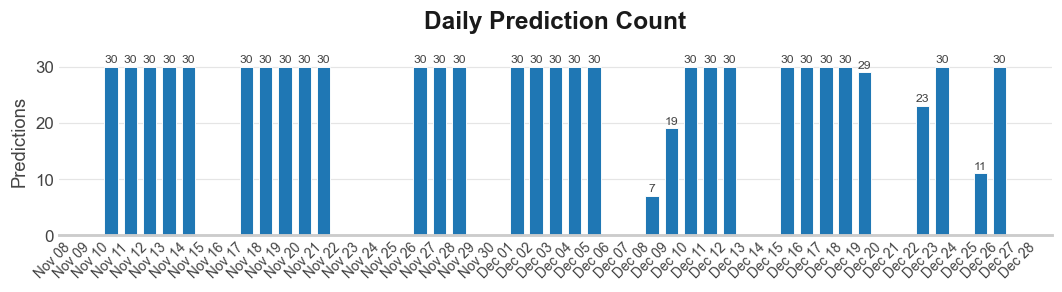

In [7]:
ts_count = df.groupby(df['collection_timestamp'].dt.date).size()

fig, ax = plt.subplots(figsize=(10, 3))

bars = ax.bar(ts_count.index, ts_count.values, color='tab:blue',
              edgecolor='white', linewidth=0.6, width=0.7)

# Value label on top of each bar
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.4,
                f'{int(height)}', ha='center', va='bottom',
                fontsize=8, color='#444444')

ax.set_title('Daily Prediction Count', fontsize=16)
ax.set_ylabel('Predictions')
ax.set_xlabel('')
ax.set_ylim(0, ts_count.max() * 1.12)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

style_axes(ax)
plt.tight_layout()
plt.show()


## Exploratory Data Summary
This section describes the main dataset features and highlights the variables that are essential for accuracy analysis. We focus on predicted and actual percentage changes for the day, week, and month horizons.

In [8]:
print('Unique tickers:', df['ticker'].nunique())
print('Date range:', df['collection_timestamp'].min(), 'to', df['collection_timestamp'].max())
print('Confidence categories:', df['confidence'].value_counts().to_dict())

Unique tickers: 30
Date range: 2025-11-10 15:56:30.213013 to 2025-12-26 20:26:36.359652
Confidence categories: {'Medium': 885, 'High': 11, 'Low': 3}


In [9]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

In [10]:
numeric_cols = [
    'start_price',
    
#    'pred_day', 'actual_close_day',
#    'pred_week', 'actual_close_week',
#    'pred_month', 'actual_close_month',
    
    'pred_change_day_%', 'actual_change_day_%',
    'pred_change_week_%', 'actual_change_week_%',
    'pred_change_month_%', 'actual_change_month_%',

    'error_day_%', 'error_week_%', 'error_month_%',
    
    'num_sources', 'prompt_tokens', 'completion_tokens', 'total_tokens',
]


desc = df[numeric_cols].describe(percentiles=[.05, .25, .5, .75, .95]).T
desc['skewness'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurt()
desc = desc[['count','mean','std','min','5%','25%','50%','75%','95%','max','skewness','kurtosis']]
desc.columns = ['N','Mean','Std Dev','Min','p5','p25','Median','p75','p95','Max','Skewness','Kurtosis']
desc

,N,Mean,Std Dev,Min,p5,p25,Median,p75,p95,Max,Skewness,Kurtosis
start_price,899.0,363.919366,713.035266,17.020000,35.284000,59.560000,122.940000,275.335000,1780.104000,3969.320000,3.738348,14.124969
pred_change_day_%,899.0,0.557737,0.928113,-3.303376,-0.643433,0.150145,0.423219,0.850432,1.999892,7.000774,2.128657,11.990046
actual_change_day_%,899.0,-0.630451,1.798341,-10.945721,-3.615753,-1.452398,-0.605144,0.163272,2.271345,6.641302,-0.225224,3.910081
pred_change_week_%,899.0,2.560942,2.319815,-4.873797,-0.555701,1.424272,2.239884,3.473419,6.037881,20.010650,1.746117,9.888649
actual_change_week_%,899.0,-0.194340,4.291208,-16.702433,-7.117687,-2.654543,-0.335362,2.428388,6.904337,19.007053,0.133951,1.524217
pred_change_month_%,899.0,6.231401,4.759495,-20.161066,0.719348,3.627447,5.485232,8.150399,14.710392,30.643813,0.614638,4.978087
actual_change_month_%,899.0,3.276634,8.710458,-22.337812,-10.764557,-2.102335,2.516399,8.343384,19.193069,25.841312,0.174985,0.044118
error_day_%,899.0,1.188188,1.986274,-6.085768,-2.113369,0.147299,1.111542,2.229328,4.202657,11.116445,0.291445,2.579987
error_week_%,899.0,2.755282,4.650375,-17.290640,-4.418060,-0.021272,2.851286,5.411564,10.695624,21.713575,0.156395,1.481755
error_month_%,899.0,2.954767,9.357116,-22.358509,-12.807010,-2.872988,2.990895,8.462754,19.210472,28.871064,0.019174,0.064966


In [11]:
confidence_accuracy = []
for level, group in df.groupby('confidence'):
    confidence_accuracy.append({
        'confidence': level,
        'count': len(group),
        'day_MAE': mae(group['actual_change_day_%'], group['pred_change_day_%']),
        'week_MAE': mae(group['actual_change_week_%'], group['pred_change_week_%']),
        'month_MAE': mae(group['actual_change_month_%'], group['pred_change_month_%']),
    })
confidence_df = pd.DataFrame(confidence_accuracy).set_index('confidence')
confidence_df = confidence_df.reindex(['Low', 'Medium', 'High'])
confidence_df

,count,day_MAE,week_MAE,month_MAE
confidence,,,,
Low,3,2.155068,5.510444,5.373269
Medium,885,1.765546,4.191807,7.684540
High,11,2.689942,5.250903,10.403923


In [12]:
corr = df[numeric_cols].corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr

,start_price,pred_change_day_%,actual_change_day_%,pred_change_week_%,actual_change_week_%,pred_change_month_%,actual_change_month_%,error_day_%,error_week_%,error_month_%,num_sources,prompt_tokens,completion_tokens,total_tokens
start_price,1.000000,0.018419,0.102817,0.059913,-0.039943,0.121767,-0.231279,-0.084482,0.066745,0.277232,-0.047411,-0.059552,0.166476,-0.025721
pred_change_day_%,0.018419,1.000000,0.044977,0.590991,0.080314,0.367906,-0.006040,0.426542,0.220702,0.192758,0.016069,0.027613,0.018916,0.028362
actual_change_day_%,0.102817,0.044977,1.000000,0.071037,0.409163,0.055339,0.198177,-0.884368,-0.342125,-0.156332,0.015538,-0.011804,0.047732,-0.002578
pred_change_week_%,0.059913,0.590991,0.071037,1.000000,0.108993,0.706381,0.065661,0.211833,0.398269,0.298178,0.005897,-0.012800,-0.056340,-0.021282
actual_change_week_%,-0.039943,0.080314,0.409163,0.108993,1.000000,0.086653,0.458405,-0.332922,-0.868395,-0.382649,0.027818,0.042817,0.013942,0.041346
pred_change_month_%,0.121767,0.367906,0.055339,0.706381,0.086653,1.000000,0.132296,0.121806,0.272414,0.385497,0.043049,0.023228,0.003215,0.021686
actual_change_month_%,-0.231279,-0.006040,0.198177,0.065661,0.458405,0.132296,1.000000,-0.182248,-0.390246,-0.863599,0.027584,0.028824,-0.039126,0.019538
error_day_%,-0.084482,0.426542,-0.884368,0.211833,-0.332922,0.121806,-0.182248,1.000000,0.412880,0.231610,-0.006559,0.023590,-0.034377,0.015587
error_week_%,0.066745,0.220702,-0.342125,0.398269,-0.868395,0.272414,-0.390246,0.412880,1.000000,0.501840,-0.022728,-0.045895,-0.040970,-0.048769
error_month_%,0.277232,0.192758,-0.156332,0.298178,-0.382649,0.385497,-0.863599,0.231610,0.501840,1.000000,-0.003781,-0.015017,0.038057,-0.007157


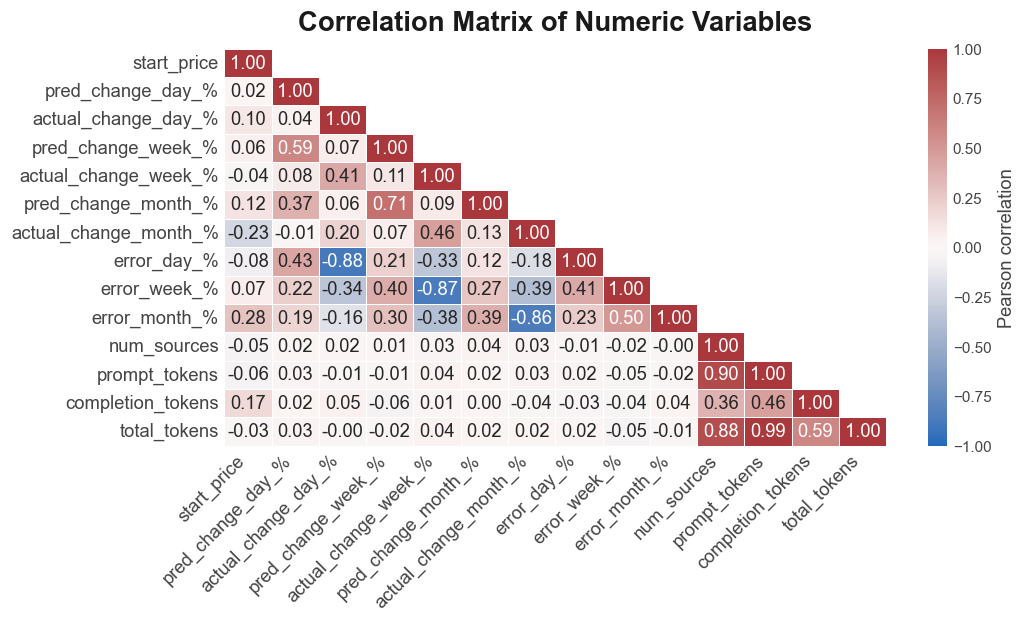

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    corr,
    mask=mask,
    cmap='vlag',
    center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f',
    annot_kws={'size': 12},
    square=False,
    linewidths=0.4, linecolor='white',
    ax=ax,
)

ax.set_title('Correlation Matrix of Numeric Variables', fontsize=18, fontweight='bold')
ax.tick_params(axis='both', labelsize=12)
ax.grid(False)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label('Pearson correlation', fontsize=12)

plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## Statistical Significance and Error Consistency
We test whether forecast errors differ significantly from zero using one-sample t-tests. We also compare whether the magnitude of errors is significantly different across horizons.

In [14]:
# =============================================================================
# Forecast bias test: H0 the model's mean forecast error is zero.
# For each horizon, aggregate errors to date level, then run a DM-style test
# (NW HAC with Bartlett kernel and lag h-1, HLN small-sample correction,
# referenced against t_{T-1}).
# An unadjusted one-sample t-test on the full 899-observation panel is reported
# alongside as a descriptive reference: it ignores the cross-sectional and
# overlap-induced dependence, so the gap between t_stat and dm_stat documents
# the magnitude of the dependence correction. It does not enter the inference.
# Sign convention: error = predicted - realized; positive => overprediction.
# =============================================================================


def _newey_west_lrv(x, lag):
    """Newey-West long-run variance estimator with Bartlett kernel."""
    n = len(x)
    x_centered = x - x.mean()
    gamma_0 = np.dot(x_centered, x_centered) / n
    lrv = gamma_0
    for k in range(1, lag + 1):
        weight = 1.0 - k / (lag + 1)
        gamma_k = np.dot(x_centered[k:], x_centered[:-k]) / n
        lrv += 2.0 * weight * gamma_k
    return lrv


def _dm_hln_test(d, h):
    """DM-style test on a univariate series d with NW HAC variance (Bartlett
    kernel, lag h-1) and HLN small-sample correction. Returns (statistic,
    two-sided p-value referenced against t_{T-1})."""
    d = np.asarray(d, dtype=float)
    n = len(d)
    lag = max(h - 1, 0)
    lrv = _newey_west_lrv(d, lag)
    stat = d.mean() / np.sqrt(lrv / n)
    hln_factor = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    stat_hln = stat * hln_factor
    p_value = 2.0 * (1.0 - stats.t.cdf(np.abs(stat_hln), df=n - 1))
    return stat_hln, p_value


def bias_test(df, horizon, h, date_col='collection_date'):
    """Test forecast unbiasedness at one horizon on date-aggregated errors,
    with an unadjusted full-panel one-sample t-test reported for reference."""
    y_pred = df[f'pred_change_{horizon}_%'].to_numpy(dtype=float)
    y_true = df[f'actual_change_{horizon}_%'].to_numpy(dtype=float)
    dates = df[date_col].to_numpy()

    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    err = (y_pred - y_true)[mask]
    err_by_date = pd.Series(err).groupby(dates[mask]).mean().sort_index().values

    dm_stat, dm_p = _dm_hln_test(err_by_date, h=h)

    # Unadjusted one-sample t-test on the full panel (reference only).
    t_stat, t_p = stats.ttest_1samp(err, 0.0)

    return {
        'horizon': horizon,
        'n_obs': int(mask.sum()),
        'n_dates': len(err_by_date),
        'mean_error': err.mean(),
        'dm_stat': dm_stat,
        'dm_p_value': dm_p,
        't_stat': t_stat,
        't_p_value': t_p,
    }


horizon_to_h = {'day': 1, 'week': 5, 'month': 21}
bias_df = pd.DataFrame(
    [bias_test(df, horizon, h) for horizon, h in horizon_to_h.items()]
).set_index('horizon').round(2)
bias_df


,n_obs,n_dates,mean_error,dm_stat,dm_p_value,t_stat,t_p_value
horizon,,,,,,,
day,899,32,1.19,8.65,0.00,17.94,0.0
week,899,32,2.76,4.74,0.00,17.76,0.0
month,899,32,2.95,1.53,0.14,9.47,0.0


In [15]:
error_cols = ['error_day_%', 'error_week_%', 'error_month_%']

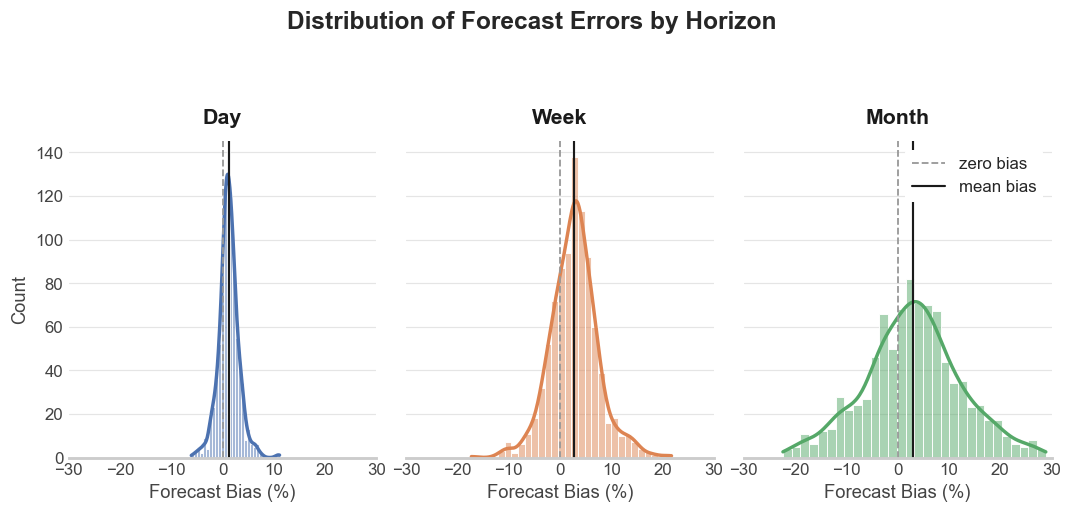

In [16]:
error_cols = ['error_day_%', 'error_week_%', 'error_month_%']

fig, axes = plt.subplots(1, 3, figsize=(10, 4.6), sharey=True)

for idx, (ax, col) in enumerate(zip(axes, error_cols)):
    sns.histplot(df[col], bins=30, kde=True, color=f'C{idx}', ax=ax,
                 edgecolor='white', linewidth=0.6, alpha=0.5)
    ax.axvline(0, color='#999999', linewidth=1.2, linestyle='--', label='zero bias')
    ax.axvline(df[col].mean(), color='#1a1a1a', linewidth=1.4, label='mean bias')
    ax.set_title(col.split('_')[1].capitalize(), fontsize=14)
    ax.set_xlabel('Forecast Bias (%)')
    ax.set_xlim(-30, 30)
    style_axes(ax)

axes[0].set_ylabel('Count')
axes[0].set_ylim(0, 145)
axes[-1].legend(loc='upper right')

fig.suptitle('Distribution of Forecast Errors by Horizon',
             fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


## Forecast Accuracy Metrics
We compute Mean Absolute Error (MAE), Root Mean Squared Error (RMSE) and Symmetric Mean Absolute Percentage Error (sMAPE) for each forecast horizon. MAE and RMSE are primary error metrics for return forecasts; sMAPE provides a more stable relative error measure when actual return values are near zero.

In [17]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean(np.square(y_true - y_pred)))

In [18]:
# =============================================================================
# Error metrics: MAE and RMSE at each horizon with date-level bootstrap CIs.
# -----------------------------------------------------------------------------
# Point estimates use the full panel. Confidence intervals come from a
# moving-block bootstrap on dates (block length = max(h - 1, 1)).
# =============================================================================



def _block_indices(T, block_len, rng):
    """Sample T date indices via a circular moving-block scheme of block_len.
    At block_len = 1 this reduces to ordinary iid resampling of dates."""
    n_blocks = int(np.ceil(T / block_len))
    starts = rng.integers(0, T, size=n_blocks)
    idx = np.concatenate([(starts[:, None] + np.arange(block_len)) % T]).ravel()
    return idx[:T]


def error_metrics(df, horizon, h, date_col='collection_date',
                  n_boot=10_000, ci=0.95, seed=20251110):
    """MAE and RMSE at one horizon with date-level moving-block bootstrap CIs."""
    y_true = df[f'actual_change_{horizon}_%'].to_numpy(dtype=float)
    y_pred = df[f'pred_change_{horizon}_%'].to_numpy(dtype=float)
    dates = df[date_col].to_numpy()

    unique_dates, date_idx = np.unique(dates, return_inverse=True)
    T = len(unique_dates)
    groups = [np.where(date_idx == t)[0] for t in range(T)]

    block_len = max(h - 1, 1)
    rng = np.random.default_rng(seed)
    boot_mae = np.empty(n_boot)
    boot_rmse = np.empty(n_boot)
    for b in range(n_boot):
        sampled_dates = _block_indices(T, block_len, rng)
        obs_idx = np.concatenate([groups[t] for t in sampled_dates])
        boot_mae[b] = mae(y_true[obs_idx], y_pred[obs_idx])
        boot_rmse[b] = rmse(y_true[obs_idx], y_pred[obs_idx])

    lo, hi = (1 - ci) / 2, 1 - (1 - ci) / 2
    return {
        'horizon': horizon,
        'n_obs': len(y_true),
        'n_dates': T,
        'MAE': mae(y_true, y_pred),
        'MAE_CI_low': np.quantile(boot_mae, lo),
        'MAE_CI_high': np.quantile(boot_mae, hi),
        'RMSE': rmse(y_true, y_pred),
        'RMSE_CI_low': np.quantile(boot_rmse, lo),
        'RMSE_CI_high': np.quantile(boot_rmse, hi),
    }


horizon_to_h = {'day': 1, 'week': 5, 'month': 21}
metrics_df = pd.DataFrame(
    [error_metrics(df, horizon, h) for horizon, h in horizon_to_h.items()]
).set_index('horizon').round(2)
metrics_df

,n_obs,n_dates,MAE,MAE_CI_low,MAE_CI_high,RMSE,RMSE_CI_low,RMSE_CI_high
horizon,,,,,,,,
day,899,32,1.78,1.58,1.98,2.31,2.08,2.53
week,899,32,4.21,3.60,4.85,5.40,4.61,6.10
month,899,32,7.71,7.38,8.02,9.81,9.43,10.17


### Baseline Comparison and Forecast Skill
This block evaluates the GPT-5-nano forecasts against a naive no-change benchmark (zero return) and reports whether the model provides a statistically significant improvement over a simple null forecast.

In [19]:
# =============================================================================
# Baseline comparison: model vs zero-prediction baseline at each horizon.
# Uses the Diebold-Mariano framework with date-level aggregation, NW HAC
# (Bartlett kernel, lag h-1), and the HLN small-sample correction.
# Reuses _newey_west_lrv and _dm_hln_test defined in the bias-test cell.
# An unadjusted paired t-test on the full 899-observation panel (baseline vs
# model absolute errors) is reported alongside as a descriptive reference; the
# gap between t_stat and dm_stat documents the dependence correction and does
# not enter the inference.
# Sign convention: positive DM statistic => model outperforms baseline.
# =============================================================================


def baseline_comparison(df, horizon, h, date_col='collection_date'):
    """Compare model predictions against a zero-prediction baseline at one
    horizon, with an unadjusted full-panel paired t-test reported for reference."""
    y_true = df[f'actual_change_{horizon}_%'].to_numpy(dtype=float)
    y_pred = df[f'pred_change_{horizon}_%'].to_numpy(dtype=float)
    y_base = np.zeros_like(y_true)
    dates = df[date_col].to_numpy()

    # Loss differential: |baseline error| - |model error|; positive => model better
    base_abs = np.abs(y_true - y_base)
    model_abs = np.abs(y_true - y_pred)
    diff = base_abs - model_abs
    diff_by_date = pd.Series(diff).groupby(dates).mean().sort_index().values

    dm_stat, dm_p = _dm_hln_test(diff_by_date, h=h)
    sd_diff = np.std(diff, ddof=1)

    # Unadjusted paired t-test on the full panel (reference only). Tests
    # mean(base_abs - model_abs); positive => model better, matching dm_stat.
    t_stat, t_p = stats.ttest_rel(base_abs, model_abs)

    return {
        'horizon': horizon,
        'n_obs': len(y_true),
        'n_dates': len(diff_by_date),
        'model_MAE': mae(y_true, y_pred),
        'baseline_MAE': mae(y_true, y_base),
        'model_RMSE': rmse(y_true, y_pred),
        'baseline_RMSE': rmse(y_true, y_base),
        'MAE_improvement': diff.mean(),
        'dm_stat': dm_stat,
        'dm_p_value': dm_p,
        't_stat': t_stat,
        't_p_value': t_p,
        'cohens_dz': diff.mean() / sd_diff if sd_diff != 0 else np.nan,
    }


horizon_to_h = {'day': 1, 'week': 5, 'month': 21}
baseline_df = pd.DataFrame(
    [baseline_comparison(df, horizon, h) for horizon, h in horizon_to_h.items()]
).set_index('horizon').round(2)
baseline_df


,n_obs,n_dates,model_MAE,baseline_MAE,model_RMSE,baseline_RMSE,MAE_improvement,dm_stat,dm_p_value,t_stat,t_p_value,cohens_dz
horizon,,,,,,,,,,,,
day,899,32,1.78,1.38,2.31,1.90,-0.40,-10.46,0.00,-13.64,0.00,-0.45
week,899,32,4.21,3.23,5.40,4.29,-0.98,-3.70,0.00,-10.25,0.00,-0.34
month,899,32,7.71,7.12,9.81,9.30,-0.59,-0.98,0.33,-2.71,0.01,-0.09


### Directional Confusion Matrix and Significance
This section presents predicted-versus-actual direction counts and evaluates whether directional accuracy exceeds a chance baseline.

In [20]:
# =============================================================================
# Directional accuracy: Pesaran-Timmermann (1992) test of directional
# independence between predicted and realized signs.
# H0: signs are independent (no directional skill)
# H1: signs are dependent (some directional information)
# Reference distribution: standard normal under the null.
# =============================================================================


def pesaran_timmermann(y_true, y_pred):
    """Pesaran-Timmermann (1992) test of directional independence.

    H0: predicted and realized signs are independent (no directional skill).
    H1: predicted and realized signs are dependent.

    Returns (hit_rate, no_skill_rate, PT_statistic, two-sided p-value)."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    s_true = (y_true > 0).astype(float)
    s_pred = (y_pred > 0).astype(float)
    n = len(s_true)

    p_hit = np.mean(s_true == s_pred)
    p_true = s_true.mean()
    p_pred = s_pred.mean()
    p_star = p_true * p_pred + (1 - p_true) * (1 - p_pred)

    var_hit = p_star * (1 - p_star) / n
    var_star = (
        ((2 * p_true - 1) ** 2) * p_pred * (1 - p_pred) / n
        + ((2 * p_pred - 1) ** 2) * p_true * (1 - p_true) / n
        + 4 * p_true * p_pred * (1 - p_true) * (1 - p_pred) / n ** 2
    )
    var_diff = var_hit - var_star
    if var_diff <= 0:
        return p_hit, p_star, np.nan, np.nan
    pt_stat = (p_hit - p_star) / np.sqrt(var_diff)
    p_value = 2.0 * (1.0 - stats.norm.cdf(np.abs(pt_stat)))
    return p_hit, p_star, pt_stat, p_value


def directional_accuracy(df, horizon):
    """Directional accuracy at one horizon, tested by Pesaran-Timmermann."""
    y_true = df[f'actual_change_{horizon}_%'].to_numpy(dtype=float)
    y_pred = df[f'pred_change_{horizon}_%'].to_numpy(dtype=float)
    hit_rate, no_skill_rate, pt_stat, pt_p = pesaran_timmermann(y_true, y_pred)
    return {
        'horizon': horizon,
        'n_obs': len(y_true),
        'p_pred_up': np.mean(y_pred > 0),
        'p_real_up': np.mean(y_true > 0),
        'hit_rate': hit_rate,
        'no_skill_rate': no_skill_rate,
        'pt_stat': pt_stat,
        'pt_p_value': pt_p,
    }


directional_df = pd.DataFrame(
    [directional_accuracy(df, h) for h in ['day', 'week', 'month']]
).set_index('horizon').round(2)
directional_df

,n_obs,p_pred_up,p_real_up,hit_rate,no_skill_rate,pt_stat,pt_p_value
horizon,,,,,,,
day,899,0.82,0.30,0.36,0.37,-0.80,0.42
week,899,0.93,0.46,0.48,0.47,0.97,0.33
month,899,0.96,0.66,0.65,0.64,1.18,0.24


## Hypothetical Directional Trading Performance
This section calculates a simple direction-based return series using the sign of the forecast. The results are descriptive and do not include trading costs or portfolio construction.

In [21]:
import yfinance as yf

In [22]:
# =============================================================================
# Hypothetical trading performance at the day horizon.
# Three cross-sectional strategies, ranked by predicted return each date:
#   Long       - equal-weight the top 5 predicted stocks
#   Short      - equal-weight short the bottom 5 predicted stocks
#   Long-Short - both legs combined (long_short = long + short)
# Benchmark: S&P 500 index (^GSPC), pulled via yfinance.
# All returns are decimal; the short return is negated so positive => profit.
# =============================================================================

def sp500_benchmark(dates):
    """S&P 500 (^GSPC) open-to-close return aligned to each trading date t.
    Used as a broad market benchmark: this is the index's full open-to-close
    return on day t, a reference for overall market direction on the days traded
    rather than a window-matched comparison to the midday-to-close strategy
    returns. Holiday dates have no index data and return NaN (dropped downstream)."""
    dates = pd.DatetimeIndex(sorted(pd.to_datetime(dates)))
    idx = yf.download('^GSPC',
                      start=dates.min() - pd.Timedelta(days=5),
                      end=dates.max() + pd.Timedelta(days=5),
                      progress=False, auto_adjust=True)
    return (idx['Close'].squeeze() / idx['Open'].squeeze() - 1.0).reindex(dates)


def strategy_returns(df, horizon='day', date_col='collection_date',
                     ticker_col='ticker', n_legs=5):
    """Per-date decimal returns for the long, short, and long-short strategies."""
    pred_col = f'pred_change_{horizon}_%'
    real_col = f'actual_change_{horizon}_%'

    records = []
    for date in sorted(df[date_col].unique()):
        g = df.loc[df[date_col] == date, [ticker_col, pred_col, real_col]]
        k = min(n_legs, len(g) // 2)  # guard for partial-coverage dates

        g_sorted = g.sort_values(pred_col)
#        print(date, g_sorted)
        bottom = g_sorted.head(k)
        top = g_sorted.tail(k)

        long_ret = top[real_col].mean() / 100.0
        short_ret = -bottom[real_col].mean() / 100.0
        records.append({'date': pd.Timestamp(date), 'long': long_ret,
                        'short': short_ret, 'long_short': long_ret + short_ret})

    return pd.DataFrame(records).set_index('date').sort_index()


def performance_summary(returns, periods_per_year=252):
    """Performance metrics from a series of per-period decimal returns."""
    r = pd.Series(returns).dropna().to_numpy(dtype=float)
    equity = np.cumprod(1 + r)
    peak = np.maximum.accumulate(equity)
    vol = r.std(ddof=1)
    return {
        'mean_return': r.mean(),
        'cumulative_return': equity[-1] - 1,
        'volatility': vol,
        'sharpe': r.mean() / vol * np.sqrt(periods_per_year) if vol > 0 else np.nan,
        'max_drawdown': ((equity - peak) / peak).min(),
        'win_rate': np.mean(r > 0),
    }


def trading_table(strat, bench):
    """Performance summary across the three strategies plus the benchmark."""
    rows = {
        'Long (top 5)': performance_summary(strat['long']),
        'Short (bottom 5)': performance_summary(strat['short']),
        'Long-Short': performance_summary(strat['long_short']),
        'S&P 500': performance_summary(bench),
    }
    return pd.DataFrame(rows).T


strat = strategy_returns(df, horizon='day')
bench = sp500_benchmark(strat.index)

# Drop the two closed-exchange collection dates (Thanksgiving, Christmas) from
# both legs and the benchmark so every series spans the same 30 trading dates.
trading_dates = bench.dropna().index
trading_summary = trading_table(strat.loc[trading_dates], bench.loc[trading_dates])
trading_summary.round(4)

,mean_return,cumulative_return,volatility,sharpe,max_drawdown,win_rate
Long (top 5),-0.0067,-0.1847,0.0118,-9.0687,-0.1985,0.2000
Short (bottom 5),0.0055,0.1780,0.0100,8.7840,-0.0337,0.6667
Long-Short,-0.0012,-0.0371,0.0116,-1.6345,-0.0812,0.4333
S&P 500,-0.0006,-0.0197,0.0079,-1.2739,-0.0430,0.5333


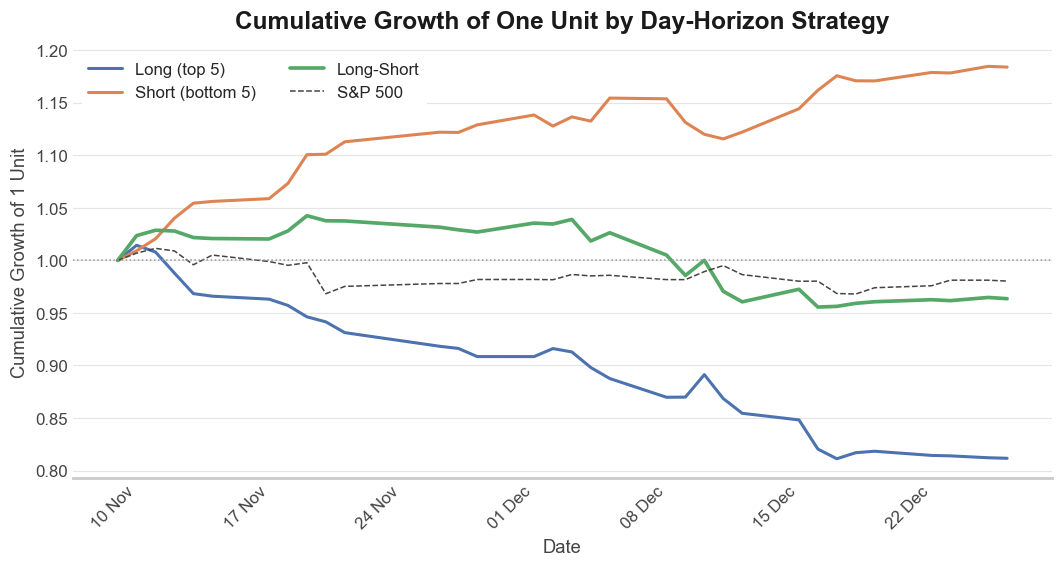

In [23]:
equity = {
    'Long (top 5)': (1 + strat['long']).cumprod(),
    'Short (bottom 5)': (1 + strat['short']).cumprod(),
    'Long-Short': (1 + strat['long_short']).cumprod(),
    'S&P 500': (1 + bench.reindex(strat.index).fillna(0)).cumprod(),
}

# Prepend an anchor one day before the first date, where every curve = 1.
anchor = strat.index.min() - pd.Timedelta(days=1)
equity = {
    label: pd.concat([pd.Series([1.0], index=[anchor]), curve]).sort_index()
    for label, curve in equity.items()
}

styles = {
    'Long (top 5)':    dict(color='C0',   linewidth=2.0),
    'Short (bottom 5)': dict(color='C1', linewidth=2.0),
    'Long-Short':      dict(color='C2',  linewidth=2.4),
    'S&P 500':         dict(color='#444444',    linewidth=1, linestyle='--'),
}

fig, ax = plt.subplots(figsize=(10, 5.5))
for label, curve in equity.items():
    ax.plot(curve.index, curve.values, label=label, **styles[label])

ax.axhline(1.0, color='#999999', linewidth=1.0, linestyle=':')
ax.set_title('Cumulative Growth of One Unit by Day-Horizon Strategy', fontsize=16)
ax.set_ylabel('Cumulative Growth of 1 Unit')
ax.set_xlabel('Date')

ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_minor_locator(mdates.DayLocator())
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

style_axes(ax)
ax.legend(loc='upper left', ncol=2)
plt.tight_layout()
plt.show()


In [24]:
import pandas as pd

# I inspect how the agent reasoned around the late-2025 market holidays.
# Of these dates the NYSE was FULLY closed only on 25 December (Christmas) and 
# 27 November (Thanksgiving); 28 November was an early-close half-day and 
# 26 December a normal full session.
holiday_dates = ['2025-11-27', '2025-11-28', '2025-12-24', '2025-12-25', '2025-12-26']
targets = sorted(pd.to_datetime(holiday_dates).date)

# Extract the date to a new column for easy filtering
df['date'] = pd.to_datetime(df['collection_timestamp']).dt.date

# Filter the DataFrame for only the target holiday dates
holiday_df = df[df['date'].isin(targets)].copy()

if holiday_df.empty:
    print("No entries in the dataset on these dates.")
else:
    # Select just the columns you want in the final table
    table_df = holiday_df[['date', 'ticker', 'confidence', 'reasoning']]
    
    # Sort chronologically, then by ticker for readability
    table_df = table_df.sort_values(by=['date', 'ticker'])
    
    # Output as a formatted text table (index=False hides the row numbers)
    print(table_df.to_string(index=False))
    
    # Tip: If you are running this inside a Jupyter Notebook, you can replace 
    # the print statement above with simply: 
    # display(table_df)

      date ticker confidence                                                                                                                                                                                                                                                                                                                                                                                                                                    reasoning
2025-11-27    ADI     Medium                                                                                                                              Post-earnings momentum and favorable guidance support upside in ADI into early December, while Thanksgiving closes the market on 2025-11-27. ([reuters.com](https://www.reuters.com/business/autos-transportation/analog-devices-sees-upbeat-quarterly-results-resilient-demand-2025-11-25/?utm_source=openai))
2025-11-27    ADM     Medium                                                        

In [25]:
# I inspect how the agent reasoned around the late-2025 market holidays.
# Of these dates the NYSE was FULLY closed only on 25 December (Christmas) and
# 27 November (Thanksgiving); 28 November was an early-close half-day and
# 26 December a normal full session.
holiday_dates = ['2025-11-27', '2025-11-28', '2025-12-24', '2025-12-25', '2025-12-26']

# I reduce the timestamp to a calendar date so the intra-batch time offsets are ignored.
coll_date = pd.to_datetime(df['collection_timestamp']).dt.date
targets   = sorted(pd.to_datetime(holiday_dates).date)

for d in targets:
    rows = df.loc[coll_date == d]
    print(f"\n{'='*80}\n{d:%d %B %Y}  —  {len(rows)} prediction(s)\n{'='*80}")
    if rows.empty:
        print("  (no entries in the dataset on this date)")
        continue
    for _, r in rows.iterrows():
        print(f"\n[{r['ticker']}]  conf={r['confidence']}")
        print(f"  {r['reasoning']}")


27 November 2025  —  30 prediction(s)

[LEN]  conf=Medium
  The near-term driver is expectations of Fed rate cuts lowering mortgage rates and boosting housing demand, which tends to lift Lennar stock in the short to medium term. ([marketwatch.com](https://www.marketwatch.com/data-news/nvr-inc-stock-outperforms-competitors-on-strong-trading-day-7a669e05-802585e827f3?utm_source=openai))

[ADM]  conf=Medium
  ADM's revised FY25 earnings outlook and ongoing commodity market dynamics are the primary drivers of near-term price movements. ([marketwatch.com](https://www.marketwatch.com/data-news/archer-daniels-midland-co-stock-outperforms-competitors-on-strong-trading-day-284e5f7b-958a540c1a87?utm_source=openai))

[NDAQ]  conf=Medium
  Positive Q3 2025 results and an upgrade from Morgan Stanley support upside potential amid a constructive broader market environment. ([nasdaq.com](https://www.nasdaq.com/press-release/nasdaq-reports-third-quarter-2025-results-surpassing-1-billion-solutions-quar

## Directional Accuracy and Bias by Horizon
Directional accuracy measures how often the forecast sign matches the actual sign. This is a practical lens on whether the agent captures market direction even when magnitude errors exist.

In [26]:
directional = []
for horizon in ['day', 'week', 'month']:
    y_true = df[f'actual_change_{horizon}_%']
    y_pred = df[f'pred_change_{horizon}_%']
    directional.append({
        'horizon': horizon,
        'directional_accuracy': np.mean(np.sign(y_true) == np.sign(y_pred)),
        'positive_actual_rate': np.mean(y_true > 0),
        'positive_pred_rate': np.mean(y_pred > 0),
    })
directional_df = pd.DataFrame(directional).set_index('horizon')
directional_df

,directional_accuracy,positive_actual_rate,positive_pred_rate
horizon,,,
day,0.337041,0.304783,0.822024
week,0.473860,0.462736,0.931034
month,0.651835,0.657397,0.958843


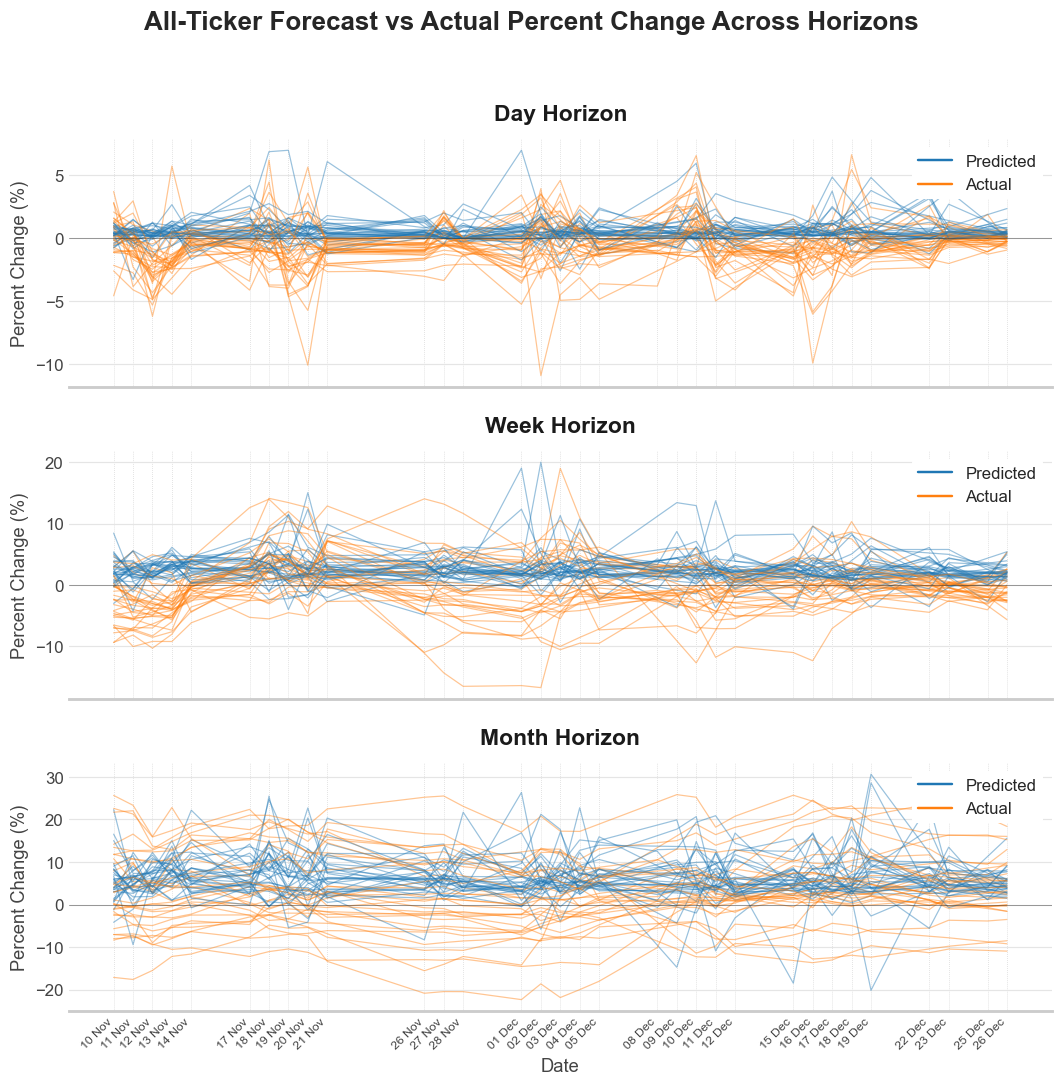

In [27]:
plot_df = df.sort_values(['ticker', 'collection_timestamp']).copy()
plot_df['date'] = pd.to_datetime(plot_df['collection_timestamp']).dt.normalize()

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

horizons = [
    ('pred_change_day_%',   'actual_change_day_%',   'Day Horizon'),
    ('pred_change_week_%',  'actual_change_week_%',  'Week Horizon'),
    ('pred_change_month_%', 'actual_change_month_%', 'Month Horizon'),
]

# All unique weekday dates
weekday_dates = pd.Series(plot_df['date'].unique()).sort_values()
weekday_dates = weekday_dates[weekday_dates.dt.dayofweek < 5]

legend_handles = [
    Line2D([], [], color='tab:blue',   linewidth=1.6, label='Predicted'),
    Line2D([], [], color='tab:orange', linewidth=1.6, label='Actual'),
]

for ax, (pred_col, actual_col, title) in zip(axes, horizons):
    for d in weekday_dates:
        ax.axvline(x=d, color='gray', linewidth=0.5, linestyle=':', alpha=0.35, zorder=0)

    for ticker, group in plot_df.groupby('ticker'):
        group = group.sort_values('date')
        ax.plot(group['date'], group[pred_col],   color='tab:blue',   linewidth=0.8, alpha=0.45)
        ax.plot(group['date'], group[actual_col], color='tab:orange', linewidth=0.8, alpha=0.45)

    ax.axhline(0, color='#1a1a1a', linewidth=0.5, alpha=0.5)
    ax.set_title(title)
    ax.set_ylabel('Percent Change (%)')
    ax.legend(handles=legend_handles, loc='upper right')
    style_axes(ax)

axes[-1].set_xlabel('Date')
axes[-1].set_xticks(weekday_dates)
axes[-1].set_xticklabels([d.strftime('%d %b') for d in weekday_dates],
                         rotation=45, ha='right', fontsize=8)

fig.suptitle('All-Ticker Forecast vs Actual Percent Change Across Horizons',
             fontsize=17, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()


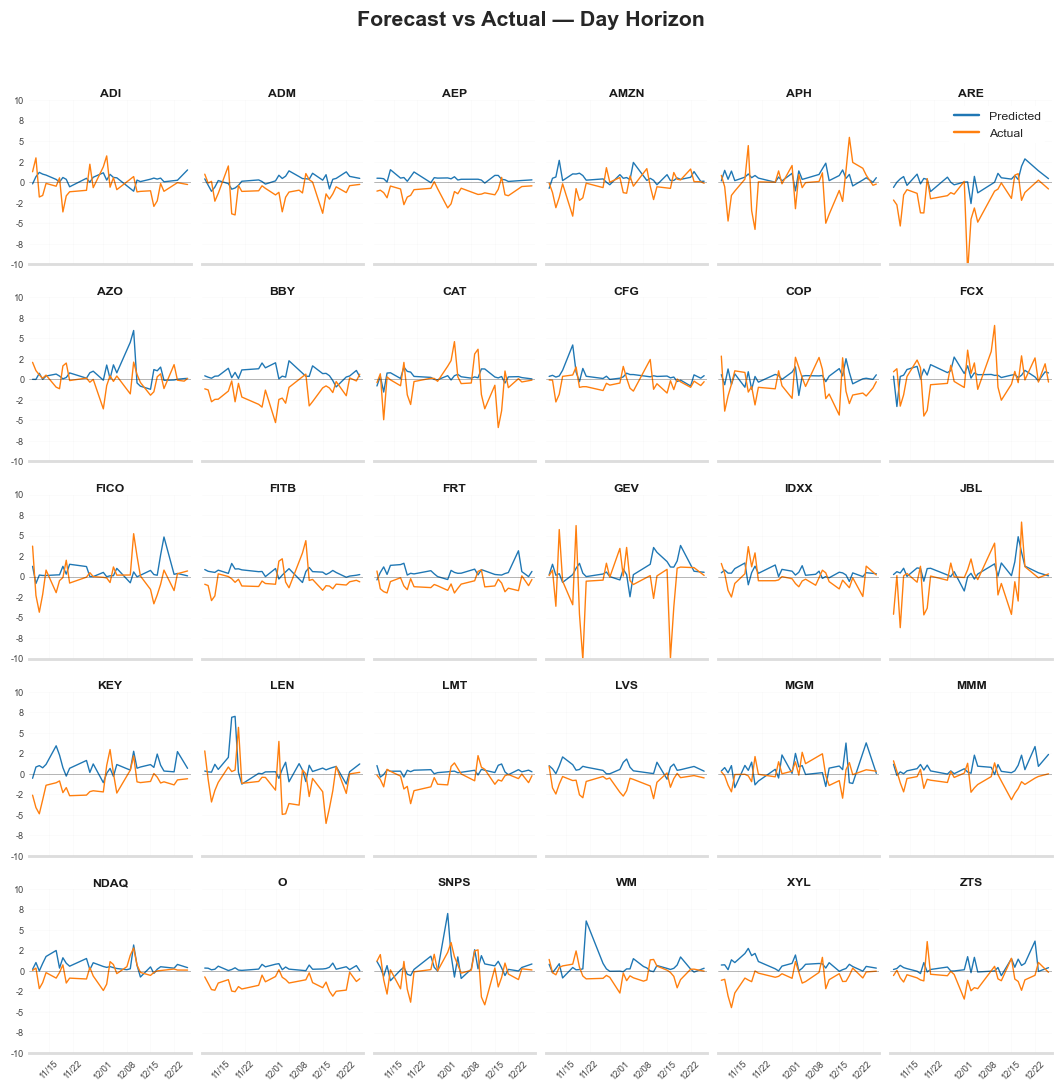

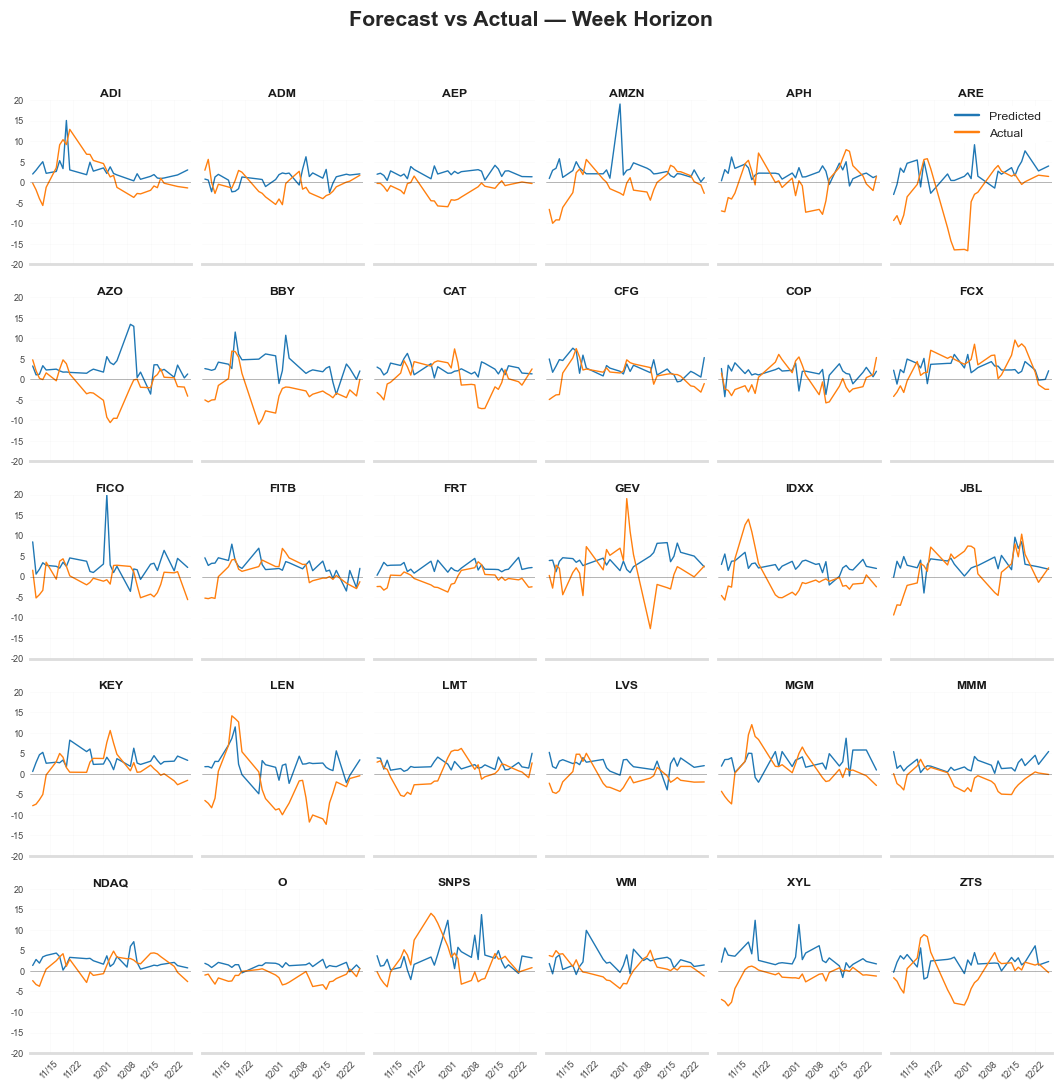

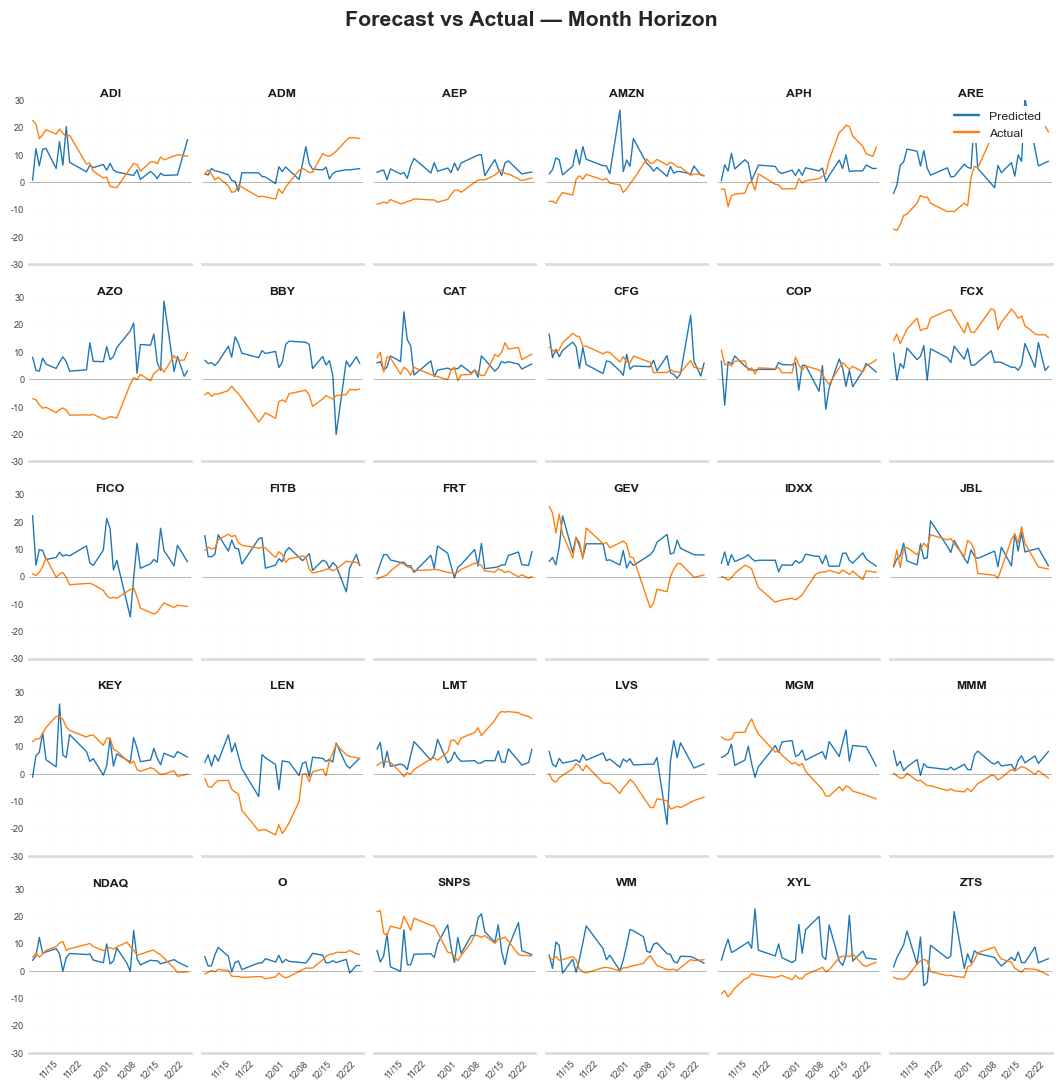

In [28]:
plot_df = df.sort_values(['ticker', 'collection_timestamp']).copy()
plot_df['date'] = pd.to_datetime(plot_df['collection_timestamp']).dt.normalize()

tickers = sorted(plot_df['ticker'].unique())
n_tickers = len(tickers)
NCOLS = 6
NROWS = math.ceil(n_tickers / NCOLS)

# Proxy handles so the legend works independently of plot order.
legend_handles = [
    Line2D([], [], color='tab:blue',   linewidth=1.6, label='Predicted'),
    Line2D([], [], color='tab:orange', linewidth=1.6, label='Actual'),
]

horizons = [
    ('pred_change_day_%',   'actual_change_day_%',   'Day Horizon',   10),
    ('pred_change_week_%',  'actual_change_week_%',  'Week Horizon',  20),
    ('pred_change_month_%', 'actual_change_month_%', 'Month Horizon', 30),
]

for pred_col, actual_col, horizon_label, ylim in horizons:

    fig, axes = plt.subplots(
        NROWS, NCOLS,
        figsize=(10,10),
        sharex=True, sharey=True
    )
    axes_flat = axes.flatten()

    for i, ticker in enumerate(tickers):
        ax = axes_flat[i]
        grp = plot_df[plot_df['ticker'] == ticker].sort_values('date')

        ax.plot(grp['date'], grp[pred_col],   color='tab:blue',   linewidth=0.9, label='Predicted')
        ax.plot(grp['date'], grp[actual_col], color='tab:orange', linewidth=0.9, label='Actual')

        ax.axhline(0, color='#1a1a1a', linewidth=0.4, alpha=0.5)
        ax.set_ylim(-ylim, ylim)
        ax.set_title(ticker, fontsize=8, fontweight='bold', pad=2)
        ax.tick_params(axis='x', labelsize=6, rotation=45, length=0)
        ax.tick_params(axis='y', labelsize=6, length=0)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}'))
        ax.grid(alpha=0.25, linewidth=0.4)
        ax.margins(x=0.02)
        for spine in ('top', 'right', 'left'):
            ax.spines[spine].set_visible(False)
        ax.spines['bottom'].set_color('#dddddd')

        if i < (NROWS - 1) * NCOLS:
            plt.setp(ax.get_xticklabels(), visible=False)
        else:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    axes_flat[NCOLS - 1].legend(handles=legend_handles, loc='upper right', fontsize=8)

    fig.suptitle(f'Forecast vs Actual — {horizon_label}',
                 fontsize=14, fontweight='bold', y=1.0)
    plt.tight_layout(h_pad=0.6, w_pad=0.4)
    plt.show()


# Appendix

In [29]:
# =============================================================================
# Hypothetical trading performance at the day horizon.
# Cross-sectional strategies ranked by predicted return each date.
# Slices: Top/Bottom 3, 5, and 10 stocks.
# Benchmark: S&P 500 index (^GSPC), pulled via yfinance.
# All returns are decimal; the short return is negated so positive => profit.
# =============================================================================


def strategy_returns(
    df, horizon="day", date_col="collection_date", ticker_col="ticker"
):
    """Per-date decimal returns for various leg-sized strategies (3, 5, 10)

    and full-universe baseline portfolios.
    """
    pred_col = f"pred_change_{horizon}_%"
    real_col = f"actual_change_{horizon}_%"

    records = []
    for date in sorted(df[date_col].unique()):
        g = df.loc[df[date_col] == date, [ticker_col, pred_col, real_col]]
        g_sorted = g.sort_values(pred_col)
        n_available = len(g)

        # Initialize per-date record
        row_metrics = {"date": pd.Timestamp(date)}

        # Universe baseline strategies
        row_metrics["long_all"] = g[real_col].mean() / 100.0
        row_metrics["short_all"] = -g[real_col].mean() / 100.0

        # Dynamically loop through your target slice sizes
        for n in [3, 5, 10]:
            k = min(n, n_available // 2)  # guard for partial-coverage dates

            if k > 0:
                bottom = g_sorted.head(k)
                top = g_sorted.tail(k)

                long_ret = top[real_col].mean() / 100.0
                short_ret = -bottom[real_col].mean() / 100.0
            else:
                long_ret = 0.0
                short_ret = 0.0

            row_metrics[f"long_{n}"] = long_ret
            row_metrics[f"short_{n}"] = short_ret
            row_metrics[f"long_short_{n}"] = long_ret + short_ret

        records.append(row_metrics)

    return pd.DataFrame(records).set_index("date").sort_index()


def performance_summary(returns, periods_per_year=252):
    """Performance metrics from a series of per-period decimal returns."""
    r = pd.Series(returns).dropna().to_numpy(dtype=float)
    equity = np.cumprod(1 + r)
    peak = np.maximum.accumulate(equity)
    vol = r.std(ddof=1)
    return {
        "mean_return": r.mean(),
        "cumulative_return": equity[-1] - 1,
        "volatility": vol,
        "sharpe": (
            r.mean() / vol * np.sqrt(periods_per_year) if vol > 0 else np.nan
        ),
        "max_drawdown": ((equity - peak) / peak).min(),
        "win_rate": np.mean(r > 0),
    }


def trading_table(strat, bench):
    """Performance summary across all strategy variants plus the benchmark."""
    rows = {
        # Long Legs
        "Long (top 3)": performance_summary(strat["long_3"]),
        "Long (top 5)": performance_summary(strat["long_5"]),
        "Long (top 10)": performance_summary(strat["long_10"]),
        "Long All": performance_summary(strat["long_all"]),
        # Short Legs
        "Short (bottom 3)": performance_summary(strat["short_3"]),
        "Short (bottom 5)": performance_summary(strat["short_5"]),
        "Short (bottom 10)": performance_summary(strat["short_10"]),
        "Short All": performance_summary(strat["short_all"]),
        # Combined Spreads
        "Long-Short (top/bottom 3)": performance_summary(strat["long_short_3"]),
        "Long-Short (top/bottom 5)": performance_summary(strat["long_short_5"]),
        "Long-Short (top/bottom 10)": performance_summary(
            strat["long_short_10"]
        ),
        # Benchmark
        "S&P 500": performance_summary(bench),
    }
    return pd.DataFrame(rows).T

strat = strategy_returns(df, horizon='day')
bench = sp500_benchmark(strat.index)

# Drop the two closed-exchange collection dates (Thanksgiving, Christmas) from
# both legs and the benchmark so every series spans the same 30 trading dates.
trading_dates = bench.dropna().index
trading_summary = trading_table(strat.loc[trading_dates], bench.loc[trading_dates])
trading_summary.round(4)

,mean_return,cumulative_return,volatility,sharpe,max_drawdown,win_rate
Long (top 3),-0.0047,-0.1331,0.0134,-5.5030,-0.1600,0.2667
Long (top 5),-0.0067,-0.1847,0.0118,-9.0687,-0.1985,0.2000
Long (top 10),-0.0055,-0.1552,0.0112,-7.8606,-0.1622,0.2333
Long All,-0.0065,-0.1784,0.0078,-13.3047,-0.1805,0.1333
Short (bottom 3),0.0065,0.2114,0.0109,9.4143,-0.0211,0.7000
Short (bottom 5),0.0055,0.1780,0.0100,8.7840,-0.0337,0.6667
Short (bottom 10),0.0066,0.2167,0.0067,15.5425,-0.0140,0.8667
Short All,0.0065,0.2135,0.0078,13.3047,-0.0222,0.8667
Long-Short (top/bottom 3),0.0018,0.0531,0.0131,2.1942,-0.0502,0.6000
Long-Short (top/bottom 5),-0.0012,-0.0371,0.0116,-1.6345,-0.0812,0.4333


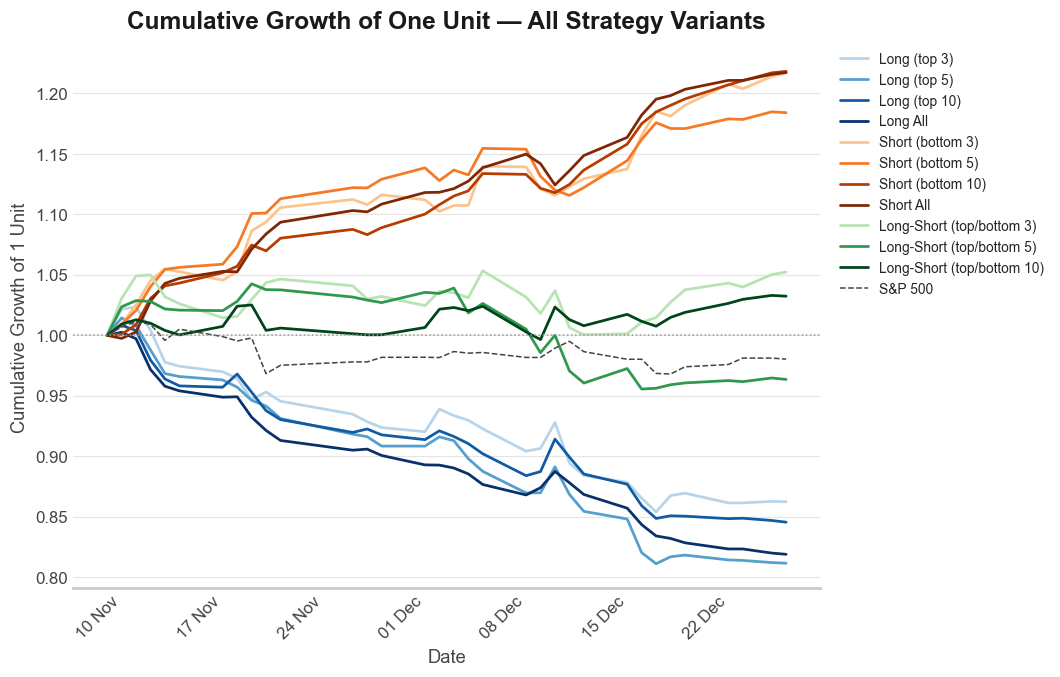

In [30]:
# Calculate cumulative returns for 12 strategy variants
equity = {
    'Long (top 3)':  (1 + strat['long_3']).cumprod(),
    'Long (top 5)':  (1 + strat['long_5']).cumprod(),
    'Long (top 10)': (1 + strat['long_10']).cumprod(),
    'Long All':      (1 + strat['long_all']).cumprod(),
    'Short (bottom 3)':  (1 + strat['short_3']).cumprod(),
    'Short (bottom 5)':  (1 + strat['short_5']).cumprod(),
    'Short (bottom 10)': (1 + strat['short_10']).cumprod(),
    'Short All':         (1 + strat['short_all']).cumprod(),
    'Long-Short (top/bottom 3)':  (1 + strat['long_short_3']).cumprod(),
    'Long-Short (top/bottom 5)':  (1 + strat['long_short_5']).cumprod(),
    'Long-Short (top/bottom 10)': (1 + strat['long_short_10']).cumprod(),
    'S&P 500': (1 + bench.reindex(strat.index).fillna(0)).cumprod(),
}

# Prepend an anchor one day before the first date, where every curve = 1.
anchor = strat.index.min() - pd.Timedelta(days=1)
equity = {
    label: pd.concat([pd.Series([1.0], index=[anchor]), curve]).sort_index()
    for label, curve in equity.items()
}

# Colour by strategy family (blue/orange/green), shaded by concentration, so
# related variants read as a group rather than a tangle of unrelated colours.
family_cmap = {'Long': 'Blues', 'Short': 'Oranges', 'Long-Short': 'Greens'}


def family_of(label):
    if label.startswith('Long-Short'):
        return 'Long-Short'
    if label.startswith('Long'):
        return 'Long'
    return 'Short'


groups = {'Long': [], 'Short': [], 'Long-Short': []}
for label in equity:
    if label != 'S&P 500':
        groups[family_of(label)].append(label)

fig, ax = plt.subplots(figsize=(10, 6.5))
for family, labels in groups.items():
    cmap = plt.get_cmap(family_cmap[family])
    for i, label in enumerate(labels):
        shade = cmap(0.30 + 0.80 * i / max(len(labels) - 1, 1))
        ax.plot(equity[label].index, equity[label].values,
                label=label, color=shade, linewidth=1.8)

ax.plot(equity['S&P 500'].index, equity['S&P 500'].values,
        label='S&P 500', color='#444444', linewidth=1, linestyle='--')

ax.axhline(1.0, color='#999999', linewidth=1.0, linestyle=':')
ax.set_title('Cumulative Growth of One Unit \u2014 All Strategy Variants', fontsize=16)
ax.set_ylabel('Cumulative Growth of 1 Unit')
ax.set_xlabel('Date')

ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

style_axes(ax)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.0, fontsize=9)
plt.tight_layout()
plt.show()
